## 2.5 쇼어 알고리즘 — 양자 인수분해 (Shor's Algorithm)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_2527/1244482959.py:22: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(3, do_swaps=False).inverse(), [0, 1, 2])


Counts: {'0000': 1024}


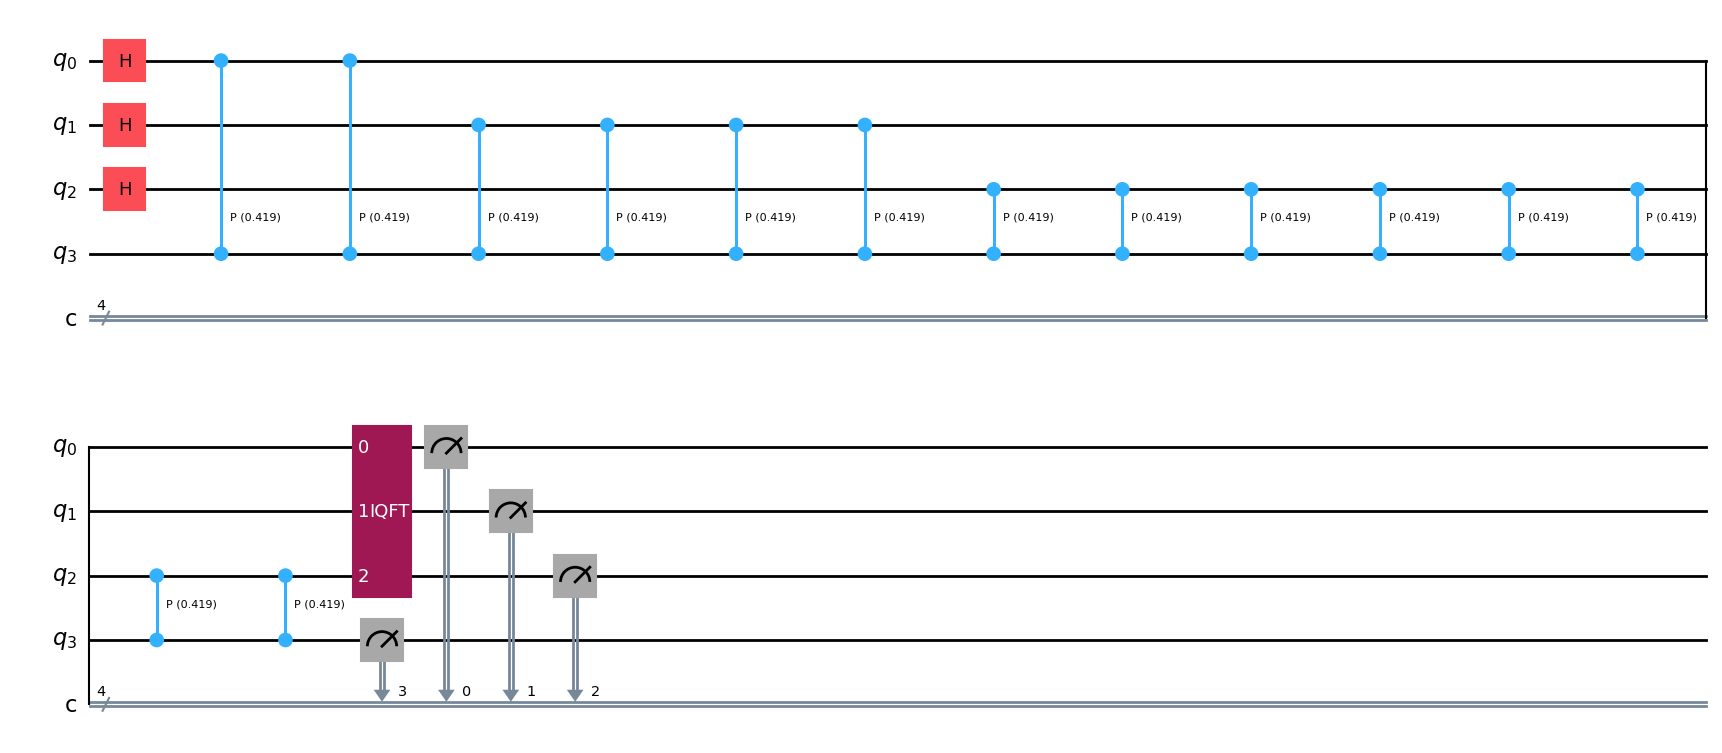

In [2]:
# 제어 모듈러 지수를 만드는 함수 (단순화)
def controlled_mod_exp(qc, base, exponent, modulus, control, target):
    for _ in range(exponent):
        qc.cp(2 * 3.1415 / modulus, control, target)

# 알고리즘 파라미터 (단순화된 예제)
N = 15  # 인수분해 대상 (예: 15 = 3 * 5)
base = 7  # 모듈러 지수의 밑

# 양자 회로 생성
qc = QuantumCircuit(4, 4)

# 앞의 세 큐비트에 하다마드 게이트로 중첩 생성
qc.h([0, 1, 2])

# 제어 모듈러 지수 수행
controlled_mod_exp(qc, base, 2, N, 0, 3)
controlled_mod_exp(qc, base, 4, N, 1, 3)
controlled_mod_exp(qc, base, 8, N, 2, 3)

# 역 양자 푸리에 변환 적용
qc.append(QFT(3, do_swaps=False).inverse(), [0, 1, 2])

# 큐비트 측정
qc.measure([0, 1, 2, 3], [0, 1, 2, 3])

# Qiskit Aer 시뮬레이터로 회로 실행
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

# 측정 결과 집계
counts = result.get_counts()

print("Counts:", counts)

# 측정 결과 시각화
plot_histogram(counts)
plt.show()
qc.draw('mpl')

# 참고: 위 controlled_mod_exp 는 흐름을 보여 주기 위한 토이 구현이라 측정이 한 값에 몰린다.
#       정식 쇼어는 모듈러 지수를 제대로 구현해 주기 r 을 추출한다. (이론 노트 2.5 참고)